# Machine Learning : Topic Modeling on Mental Health Tweets  
**Author**: Rohit Kumar Malik  
**Dataset**: Sentiment Analysis for Mental Health (Kaggle)
**Objective**: Perform topic modeling to uncover themes in mental health-related tweets using TF-IDF, LDA, and K-Means.


## 1. Library Imports and Setup
We start by importing the required libraries for data manipulation, natural language processing, machine learning, and visualization. We also set up Google Drive access and download necessary NLTK resources.


In [17]:
# Data manipulation and analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Natural Language Processing
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob

# Machine Learning and Topic Modeling
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE

# Visualization
import wordcloud
from wordcloud import WordCloud
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Google Drive integration
from google.colab import drive

# Download required NLTK data
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('omw-1.4')
print("All NLTK resources downloaded successfully!")

print("All libraries imported successfully!")

All NLTK resources downloaded successfully!
All libraries imported successfully!


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## 2. Load Dataset from Google Drive
We load the dataset from Google Drive and inspect its structure. We ensure all required columns are present and check for any missing or malformed data.


In [18]:
# Mount Google Drive to access the dataset
drive.mount('/content/drive')

# Load the dataset from Google Drive
# Note: Update the path according to your file location in Google Drive
file_path = '/content/drive/MyDrive/Mental-Health-Twitter.csv'  # Update this path as needed

try:
    # Read the CSV file
    df = pd.read_csv(file_path)
    print(f"Dataset loaded successfully!")
    print(f"Dataset shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")

    # Display basic information about the dataset
    print("\n" + "="*50)
    print("DATASET OVERVIEW")
    print("="*50)
    print(f"Total records: {len(df)}")
    print(f"Total features: {len(df.columns)}")

    # Display first few rows
    print("\nFirst 5 rows:")
    print(df.head())

    # Check for missing values
    print(f"\nMissing values:\n{df.isnull().sum()}")

    # Display data types
    print(f"\nData types:\n{df.dtypes}")

except Exception as e:
    print(f"Error loading dataset: {e}")
    print("Please check the file path and ensure the CSV file is in your Google Drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully!
Dataset shape: (20000, 11)
Columns: ['Unnamed: 0', 'post_id', 'post_created', 'post_text', 'user_id', 'followers', 'friends', 'favourites', 'statuses', 'retweets', 'label']

DATASET OVERVIEW
Total records: 20000
Total features: 11

First 5 rows:
   Unnamed: 0             post_id                    post_created  \
0           0  637894677824413696  Sun Aug 30 07:48:37 +0000 2015   
1           1  637890384576778240  Sun Aug 30 07:31:33 +0000 2015   
2           2  637749345908051968  Sat Aug 29 22:11:07 +0000 2015   
3           3  637696421077123073  Sat Aug 29 18:40:49 +0000 2015   
4           4  637696327485366272  Sat Aug 29 18:40:26 +0000 2015   

                                           post_text     user_id  followers  \
0  It's just over 2 years since I was diagnosed w...  1013187241         84   
1  It's Sunday, I need 

## 3. Data Cleaning and Preprocessing
We clean the text data by removing URLs, mentions, special characters, and perform lemmatization and stopword removal. This prepares the data for feature extraction.


In [19]:
# Rename relevant columns to match existing pipeline logic
df.rename(columns={'post_text': 'statement', 'label': 'status'}, inplace=True)

def clean_text(text):
    """
    Comprehensive text cleaning function
    - Remove URLs, mentions, hashtags
    - Remove special characters and numbers
    - Convert to lowercase
    - Remove extra whitespace
    """
    if pd.isna(text):
        return ""

    # Convert to string
    text = str(text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove user mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)

    # Remove special characters and numbers, keep only letters and spaces
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Convert to lowercase
    text = text.lower()

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

def preprocess_text(text):
    """
    Advanced text preprocessing including:
    - Tokenization
    - Stop word removal
    - Lemmatization
    """
    if not text or len(text.strip()) == 0:
        return ""

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords and short words
    stop_words = set(stopwords.words('english'))
    custom_stops = {'like', 'get', 'go', 'know', 'one', 'would', 'could', 'also', 'really', 'even', 'much'}
    stop_words.update(custom_stops)

    tokens = [token for token in tokens if token not in stop_words and len(token) > 2]

    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]

    return ' '.join(tokens)

# Apply text cleaning and preprocessing
print("\n" + "="*50)
print("TEXT PREPROCESSING")
print("="*50)

#Step 1: Clean the text data
df['cleaned_text'] = df['statement'].apply(clean_text)
print("Step 1: Basic text cleaning completed")

#Step 2: Advanced preprocessing
df['processed_text'] = df['cleaned_text'].apply(preprocess_text)
print("Step 2: Advanced preprocessing (tokenization, lemmatization) completed")

#Step 3: Remove empty texts after preprocessing
df = df[df['processed_text'].str.len() > 0].reset_index(drop=True)
print(f"Step 3: Removed empty texts. Final dataset size: {len(df)} records")

#Step 4: Filter to get required sample size
sample_size = min(5000, len(df))
df_sample = df.sample(n=sample_size, random_state=42).reset_index(drop=True)
print(f"Step 4: Selected sample of {sample_size} records for analysis")

#Step 5: Display preprocessing results
print(f"\nSample of processed texts:")
for i in range(3):
    print(f"Original: {df_sample.iloc[i]['statement']}")
    print(f"Processed: {df_sample.iloc[i]['processed_text']}")
    print("-" * 50)


TEXT PREPROCESSING
Step 1: Basic text cleaning completed
Step 2: Advanced preprocessing (tokenization, lemmatization) completed
Step 3: Removed empty texts. Final dataset size: 19849 records
Step 4: Selected sample of 5000 records for analysis

Sample of processed texts:
Original: HELP SOMEONE JUST INVENT A FOOD PILL OR FEED ME INTRAVENOUSLY
Processed: help someone invent food pill feed intravenously
--------------------------------------------------
Original: Goodsense Health and Happiness Boutique https://t.co/njSzVQXYG2
Processed: goodsense health happiness boutique
--------------------------------------------------
Original: @The_Trump_Train JOKE!! GENOCIDE?  Thought's of of deranged buffoon! HOW can a sane citizen vote for one of the mos… https://t.co/7BLR5Q0LuL
Processed: joke genocide thought deranged buffoon sane citizen vote mo
--------------------------------------------------


## 4. Exploratory Data Analysis (EDA)
We explore the cleaned data through basic statistics and visualizations such as status distribution, word count, and text length.



EXPLORATORY DATA ANALYSIS
Average text length: 38.07 characters
Average word count: 5.80 words

Status distribution:
status
1    2522
0    2478
Name: count, dtype: int64


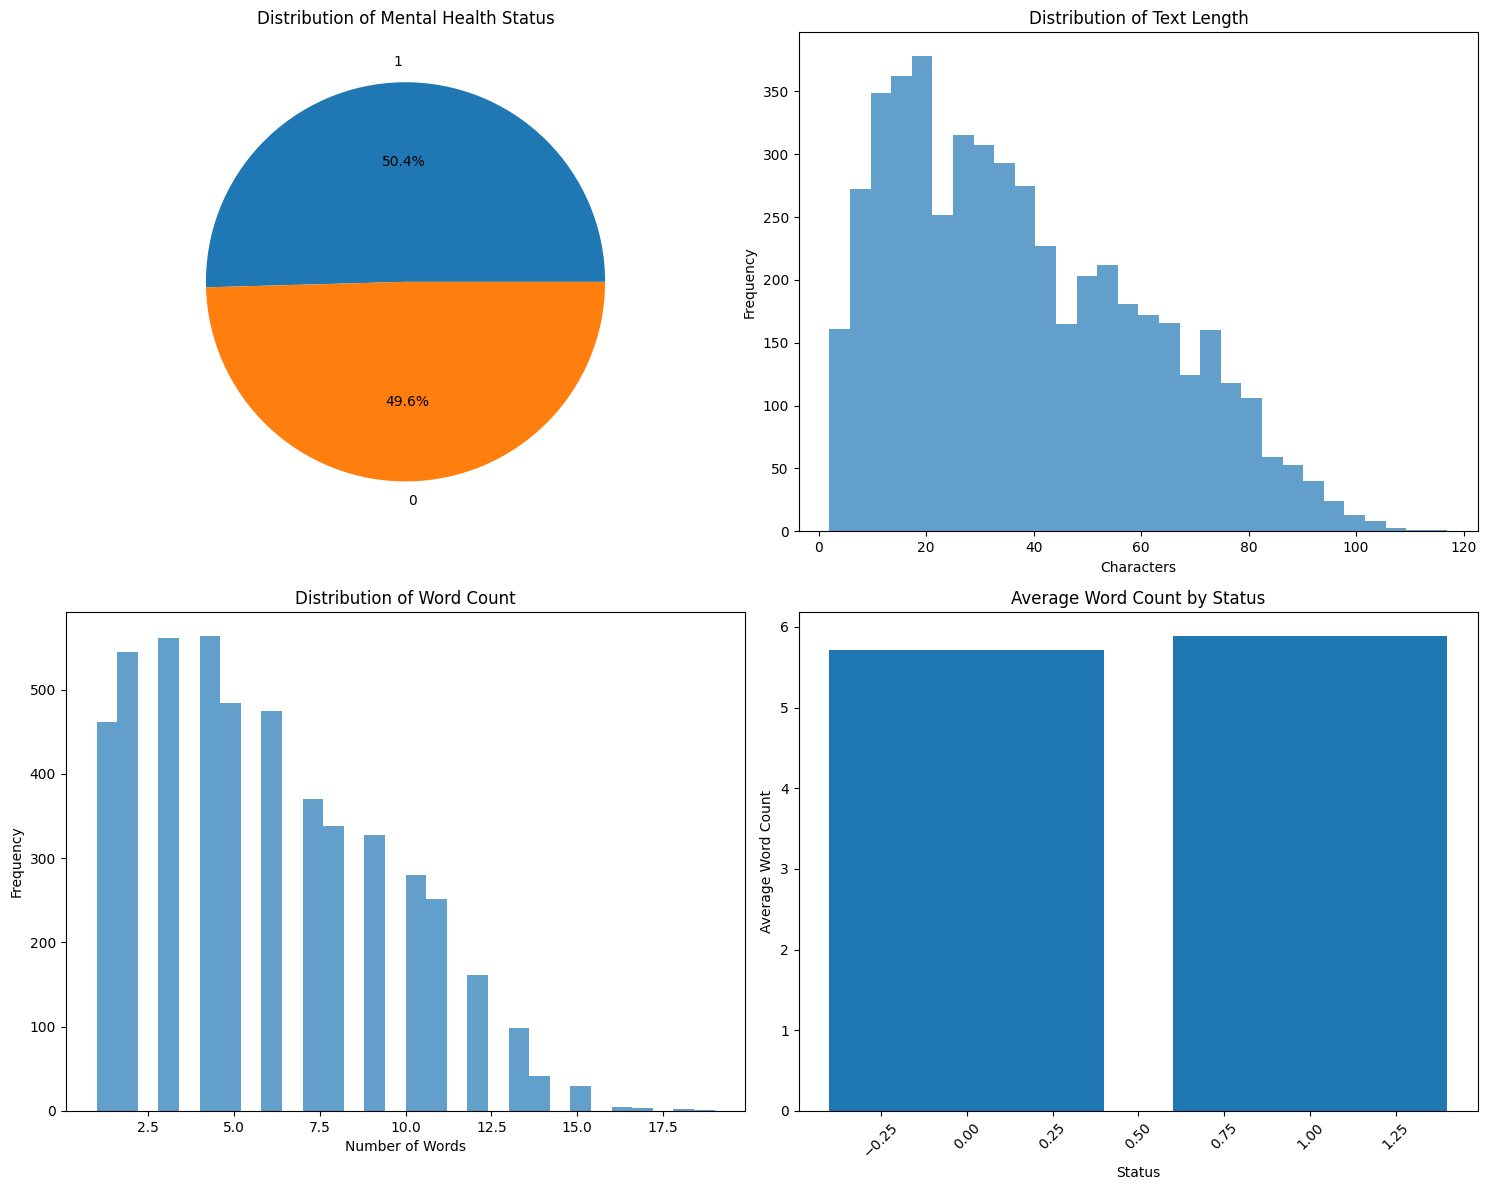

In [20]:
print("\n" + "="*50)
print("EXPLORATORY DATA ANALYSIS")
print("="*50)

# Text length analysis
df_sample['text_length'] = df_sample['processed_text'].str.len()
df_sample['word_count'] = df_sample['processed_text'].str.split().str.len()

print(f"Average text length: {df_sample['text_length'].mean():.2f} characters")
print(f"Average word count: {df_sample['word_count'].mean():.2f} words")

# Status distribution
status_counts = df_sample['status'].value_counts()
print(f"\nStatus distribution:")
print(status_counts)

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Status distribution
axes[0, 0].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%')
axes[0, 0].set_title('Distribution of Mental Health Status')

# Text length distribution
axes[0, 1].hist(df_sample['text_length'], bins=30, alpha=0.7)
axes[0, 1].set_title('Distribution of Text Length')
axes[0, 1].set_xlabel('Characters')
axes[0, 1].set_ylabel('Frequency')

# Word count distribution
axes[1, 0].hist(df_sample['word_count'], bins=30, alpha=0.7)
axes[1, 0].set_title('Distribution of Word Count')
axes[1, 0].set_xlabel('Number of Words')
axes[1, 0].set_ylabel('Frequency')

# Text length by status
status_groups = df_sample.groupby('status')['word_count'].mean()
axes[1, 1].bar(status_groups.index, status_groups.values)
axes[1, 1].set_title('Average Word Count by Status')
axes[1, 1].set_xlabel('Status')
axes[1, 1].set_ylabel('Average Word Count')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 5. Feature Extraction using TF-IDF
We convert preprocessed text into a numerical format using TF-IDF. This representation is used in both LDA and K-Means models.


In [21]:
print("\n" + "="*50)
print("FEATURE EXTRACTION - TF-IDF")
print("="*50)

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=1000,          # Limit to top 1000 features
    min_df=2,                   # Ignore terms that appear in less than 2 documents
    max_df=0.8,                 # Ignore terms that appear in more than 80% of documents
    ngram_range=(1, 2),         # Include both unigrams and bigrams
    stop_words='english'        # Additional stopword removal
)

# Fit and transform the processed text
tfidf_matrix = tfidf_vectorizer.fit_transform(df_sample['processed_text'])
feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Number of features: {len(feature_names)}")

# Display top TF-IDF features
feature_scores = tfidf_matrix.sum(axis=0).A1
top_features = sorted(zip(feature_names, feature_scores), key=lambda x: x[1], reverse=True)[:20]

print(f"\nTop 20 TF-IDF features:")
for feature, score in top_features:
    print(f"{feature}: {score:.3f}")



FEATURE EXTRACTION - TF-IDF
TF-IDF matrix shape: (5000, 1000)
Number of features: 1000

Top 20 TF-IDF features:
dont: 77.743
love: 66.430
depression: 65.142
good: 56.312
people: 54.851
day: 48.311
time: 46.909
amp: 44.600
want: 44.596
need: 43.980
make: 43.800
say: 42.994
thank: 41.645
year: 40.764
youre: 40.588
life: 39.840
got: 38.574
trump: 38.535
thats: 38.378
think: 37.933


## 6. Topic Modeling with Latent Dirichlet Allocation (LDA)
We use LDA to identify latent topics in the tweet corpus. The optimal number of topics is chosen based on perplexity scores.



TOPIC MODELING - LATENT DIRICHLET ALLOCATION
Topics: 3, Perplexity: 1383.38
Topics: 4, Perplexity: 1652.03
Topics: 5, Perplexity: 1896.76
Topics: 6, Perplexity: 2126.65
Topics: 7, Perplexity: 2401.98
Topics: 8, Perplexity: 2615.53
Topics: 9, Perplexity: 2794.74


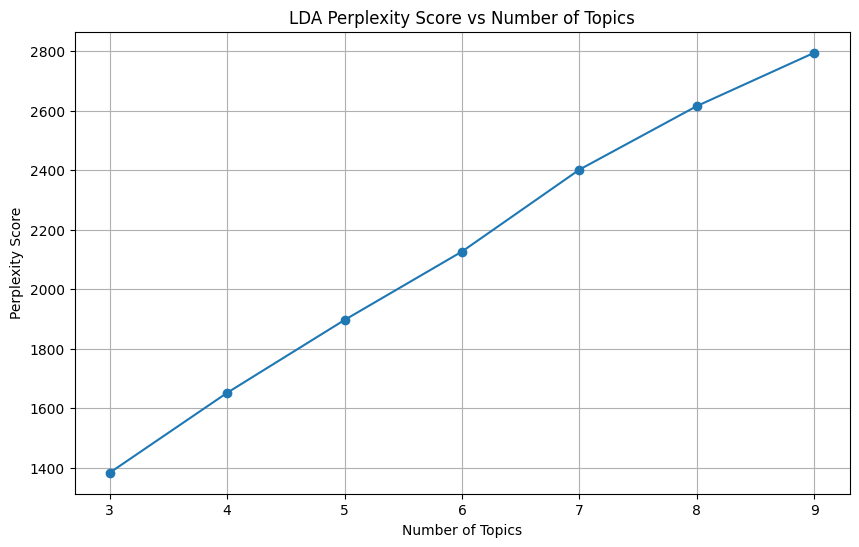


Optimal number of topics: 3
LDA model trained with 3 topics


In [22]:
print("\n" + "="*50)
print("TOPIC MODELING - LATENT DIRICHLET ALLOCATION")
print("="*50)

# Determine optimal number of topics using perplexity
def calculate_perplexity(n_topics_range, vectorizer, corpus):
    """Calculate perplexity for different numbers of topics"""
    perplexities = []

    for n_topics in n_topics_range:
        lda = LatentDirichletAllocation(
            n_components=n_topics,
            random_state=42,
            max_iter=10,
            learning_method='batch'
        )
        lda.fit(corpus)
        perplexity = lda.perplexity(corpus)
        perplexities.append(perplexity)
        print(f"Topics: {n_topics}, Perplexity: {perplexity:.2f}")

    return perplexities

# Test different numbers of topics
n_topics_range = range(3, 10)
perplexities = calculate_perplexity(n_topics_range, tfidf_vectorizer, tfidf_matrix)

# Plot perplexity scores
plt.figure(figsize=(10, 6))
plt.plot(n_topics_range, perplexities, marker='o')
plt.title('LDA Perplexity Score vs Number of Topics')
plt.xlabel('Number of Topics')
plt.ylabel('Perplexity Score')
plt.grid(True)
plt.show()

# Choose optimal number of topics (lowest perplexity)
optimal_topics = n_topics_range[np.argmin(perplexities)]
print(f"\nOptimal number of topics: {optimal_topics}")

# Train final LDA model with optimal number of topics
lda_model = LatentDirichletAllocation(
    n_components=optimal_topics,
    random_state=42,
    max_iter=20,
    learning_method='batch',
    doc_topic_prior=0.1,
    topic_word_prior=0.01
)

# Fit the model
lda_topics = lda_model.fit_transform(tfidf_matrix)
print(f"LDA model trained with {optimal_topics} topics")


## 7. Topic Interpretation and Visualization
We interpret the discovered LDA topics using top keywords and visualize their distribution and association with mental health status.



TOPIC INTERPRETATION

Topic 1:
Top words: dont, day, people, trump, want, think, friend, year

Topic 2:
Top words: depression, good, treatment, twitter, depression treatment, life, thank, migraine

Topic 3:
Top words: love, thanks, hey, new, time, need, youre, follow

Topic distribution:
0    2137
1    1348
2    1515
Name: count, dtype: int64


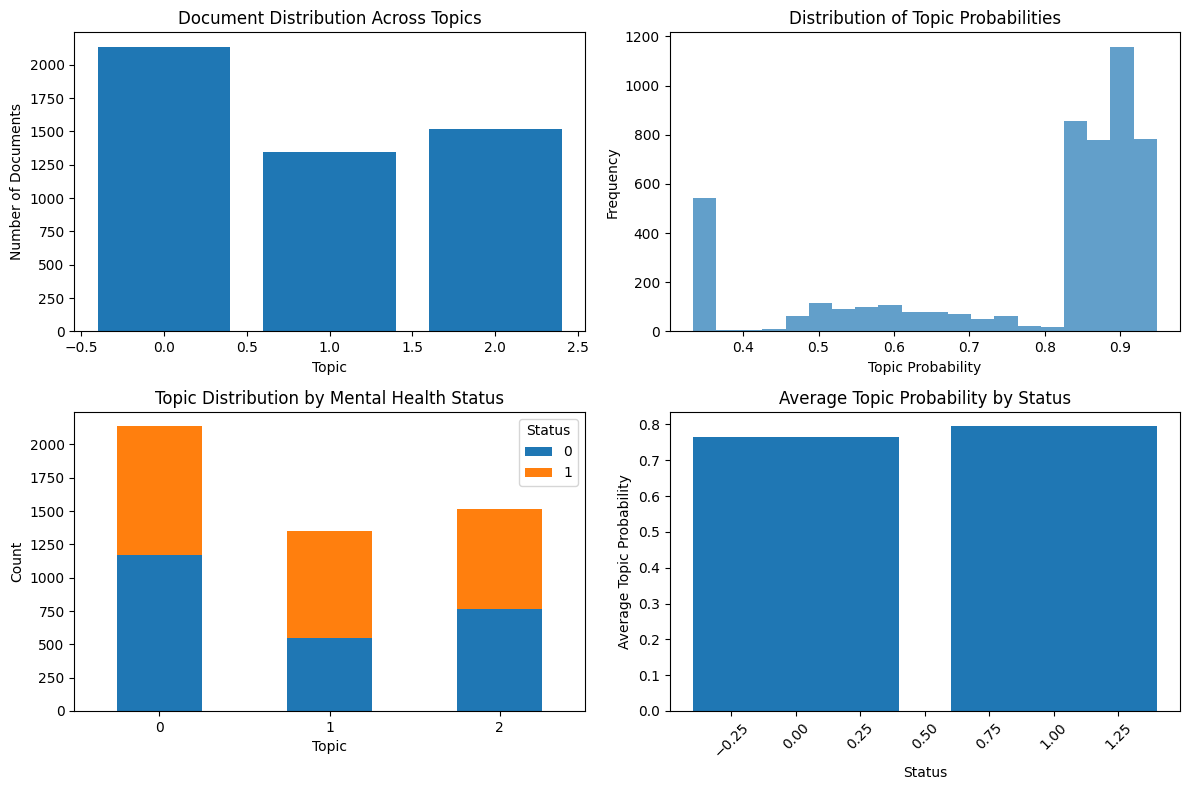

In [23]:
print("\n" + "="*50)
print("TOPIC INTERPRETATION")
print("="*50)

def display_topics(model, feature_names, n_top_words=10):
    """Display top words for each topic"""
    topics = []
    for topic_idx, topic in enumerate(model.components_):
        top_words_idx = topic.argsort()[-n_top_words:][::-1]
        top_words = [feature_names[i] for i in top_words_idx]
        top_words_scores = [topic[i] for i in top_words_idx]
        topics.append((top_words, top_words_scores))

        print(f"\nTopic {topic_idx + 1}:")
        print(f"Top words: {', '.join(top_words[:8])}")

    return topics

# Display topics
topics_info = display_topics(lda_model, feature_names)

# Assign topic labels to documents
doc_topic_assignments = np.argmax(lda_topics, axis=1)
df_sample['dominant_topic'] = doc_topic_assignments
df_sample['topic_probability'] = np.max(lda_topics, axis=1)

# Topic distribution
topic_distribution = pd.Series(doc_topic_assignments).value_counts().sort_index()
print(f"\nTopic distribution:")
print(topic_distribution)

# Visualize topic distribution
plt.figure(figsize=(12, 8))

# Topic distribution bar plot
plt.subplot(2, 2, 1)
plt.bar(range(len(topic_distribution)), topic_distribution.values)
plt.title('Document Distribution Across Topics')
plt.xlabel('Topic')
plt.ylabel('Number of Documents')

# Topic probability distribution
plt.subplot(2, 2, 2)
plt.hist(df_sample['topic_probability'], bins=20, alpha=0.7)
plt.title('Distribution of Topic Probabilities')
plt.xlabel('Topic Probability')
plt.ylabel('Frequency')

# Mental health status vs topics
plt.subplot(2, 2, 3)
topic_status_crosstab = pd.crosstab(df_sample['dominant_topic'], df_sample['status'])
topic_status_crosstab.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title('Topic Distribution by Mental Health Status')
plt.xlabel('Topic')
plt.ylabel('Count')
plt.legend(title='Status')
plt.xticks(rotation=0)

# Average topic probability by status
plt.subplot(2, 2, 4)
status_topic_prob = df_sample.groupby('status')['topic_probability'].mean()
plt.bar(status_topic_prob.index, status_topic_prob.values)
plt.title('Average Topic Probability by Status')
plt.xlabel('Status')
plt.ylabel('Average Topic Probability')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


## 8. Clustering using K-Means (For Comparison)
We use K-Means clustering on the TF-IDF matrix to compare with LDA-based topic modeling. We determine the best number of clusters using the silhouette score.



K-MEANS CLUSTERING FOR COMPARISON


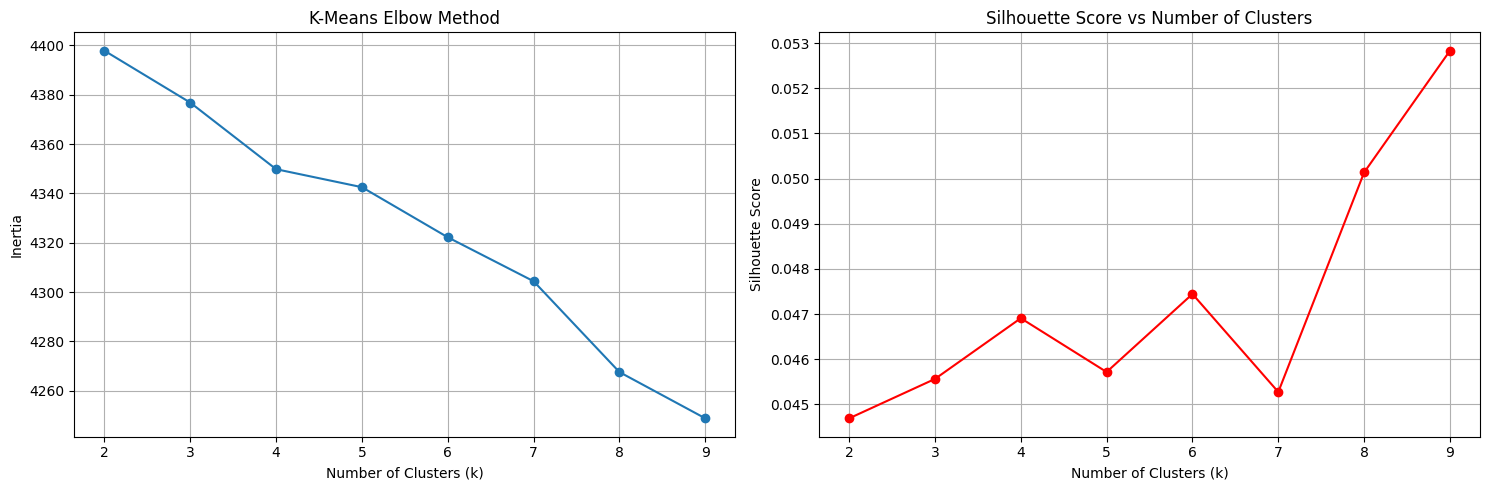

Optimal number of clusters: 9 (highest silhouette score: 0.053)


In [24]:
print("\n" + "="*50)
print("K-MEANS CLUSTERING FOR COMPARISON")
print("="*50)

# Determine optimal number of clusters using elbow method
def calculate_inertia(k_range, data):
    """Calculate inertia for different numbers of clusters"""
    inertias = []
    silhouette_scores = []

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(data)
        inertias.append(kmeans.inertia_)

        if k > 1:  # Silhouette score requires at least 2 clusters
            sil_score = silhouette_score(data, kmeans.labels_)
            silhouette_scores.append(sil_score)
        else:
            silhouette_scores.append(0)

    return inertias, silhouette_scores

# Test different numbers of clusters
k_range = range(2, 10)
inertias, sil_scores = calculate_inertia(k_range, tfidf_matrix.toarray())

# Plot elbow curve and silhouette scores
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(k_range, inertias, marker='o')
ax1.set_title('K-Means Elbow Method')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.grid(True)

ax2.plot(k_range, sil_scores, marker='o', color='red')
ax2.set_title('Silhouette Score vs Number of Clusters')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.grid(True)

plt.tight_layout()
plt.show()

# Choose optimal number of clusters
optimal_k = k_range[np.argmax(sil_scores)]
print(f"Optimal number of clusters: {optimal_k} (highest silhouette score: {max(sil_scores):.3f})")

# Train final K-Means model
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_clusters = kmeans_model.fit_predict(tfidf_matrix)

# Add cluster assignments to dataframe
df_sample['kmeans_cluster'] = kmeans_clusters


## 9. Dimensionality Reduction using t-SNE
We reduce high-dimensional data to two dimensions using t-SNE and visualize LDA topics, K-Means clusters, and mental health labels.



DIMENSIONALITY REDUCTION AND VISUALIZATION


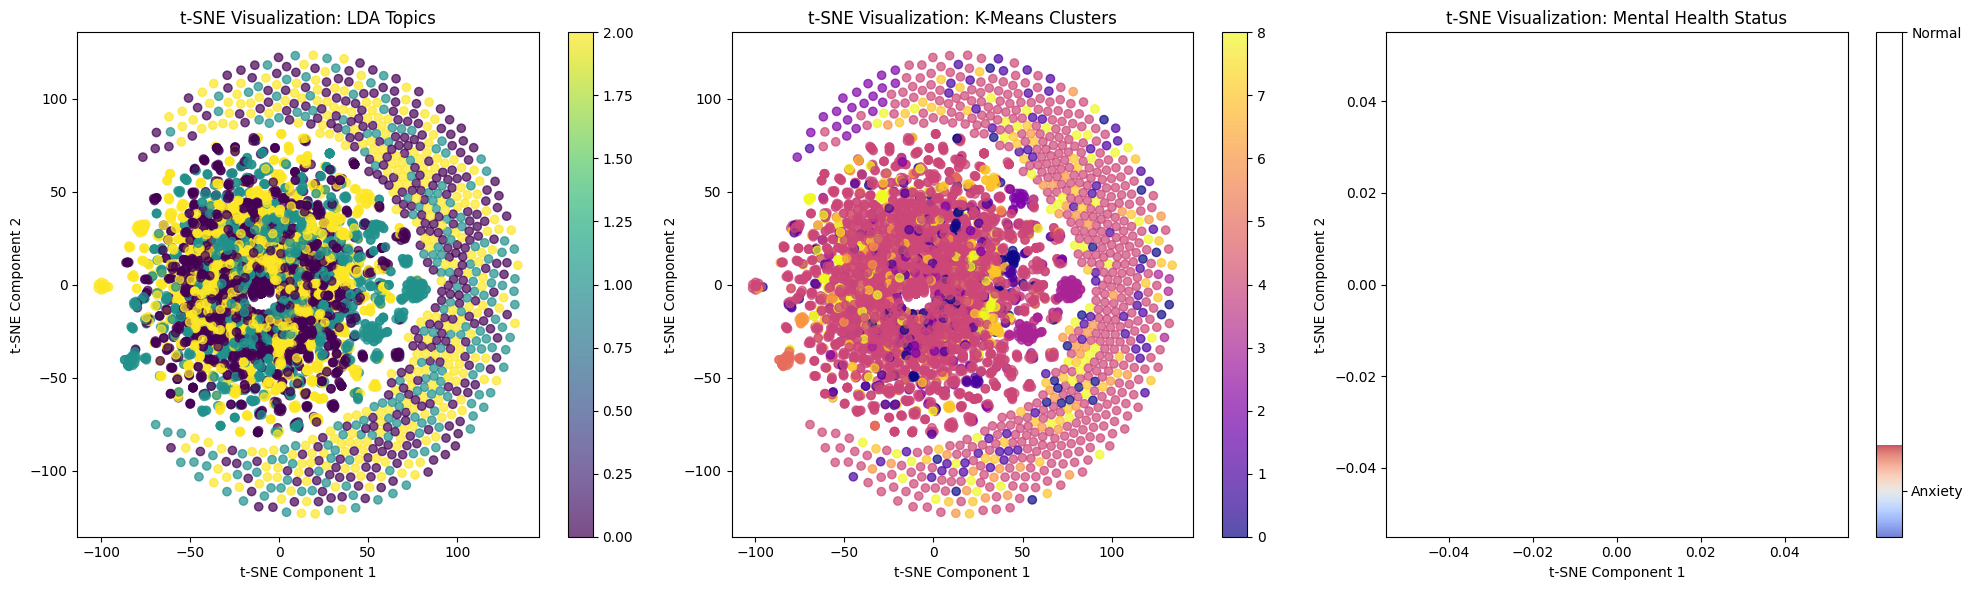

In [25]:
print("\n" + "="*50)
print("DIMENSIONALITY REDUCTION AND VISUALIZATION")
print("="*50)

# Apply t-SNE for visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
tsne_results = tsne.fit_transform(tfidf_matrix.toarray())

# Add t-SNE coordinates to dataframe
df_sample['tsne_x'] = tsne_results[:, 0]
df_sample['tsne_y'] = tsne_results[:, 1]

# Create visualization plots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# t-SNE colored by LDA topics
scatter1 = axes[0].scatter(df_sample['tsne_x'], df_sample['tsne_y'],
                          c=df_sample['dominant_topic'], cmap='viridis', alpha=0.7)
axes[0].set_title('t-SNE Visualization: LDA Topics')
axes[0].set_xlabel('t-SNE Component 1')
axes[0].set_ylabel('t-SNE Component 2')
plt.colorbar(scatter1, ax=axes[0])

# t-SNE colored by K-Means clusters
scatter2 = axes[1].scatter(df_sample['tsne_x'], df_sample['tsne_y'],
                          c=df_sample['kmeans_cluster'], cmap='plasma', alpha=0.7)
axes[1].set_title('t-SNE Visualization: K-Means Clusters')
axes[1].set_xlabel('t-SNE Component 1')
axes[1].set_ylabel('t-SNE Component 2')
plt.colorbar(scatter2, ax=axes[1])

# t-SNE colored by mental health status
status_colors = {'Anxiety': 0, 'Normal': 1}
df_sample['status_numeric'] = df_sample['status'].map(status_colors)
scatter3 = axes[2].scatter(df_sample['tsne_x'], df_sample['tsne_y'],
                          c=df_sample['status_numeric'], cmap='coolwarm', alpha=0.7)
axes[2].set_title('t-SNE Visualization: Mental Health Status')
axes[2].set_xlabel('t-SNE Component 1')
axes[2].set_ylabel('t-SNE Component 2')
cbar = plt.colorbar(scatter3, ax=axes[2])
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Anxiety', 'Normal'])

plt.tight_layout()
plt.show()


## 10. Word Clouds for Topic Representation
To better understand each topic, we generate word clouds showing the most representative terms in each discovered topic.



WORD CLOUD VISUALIZATION


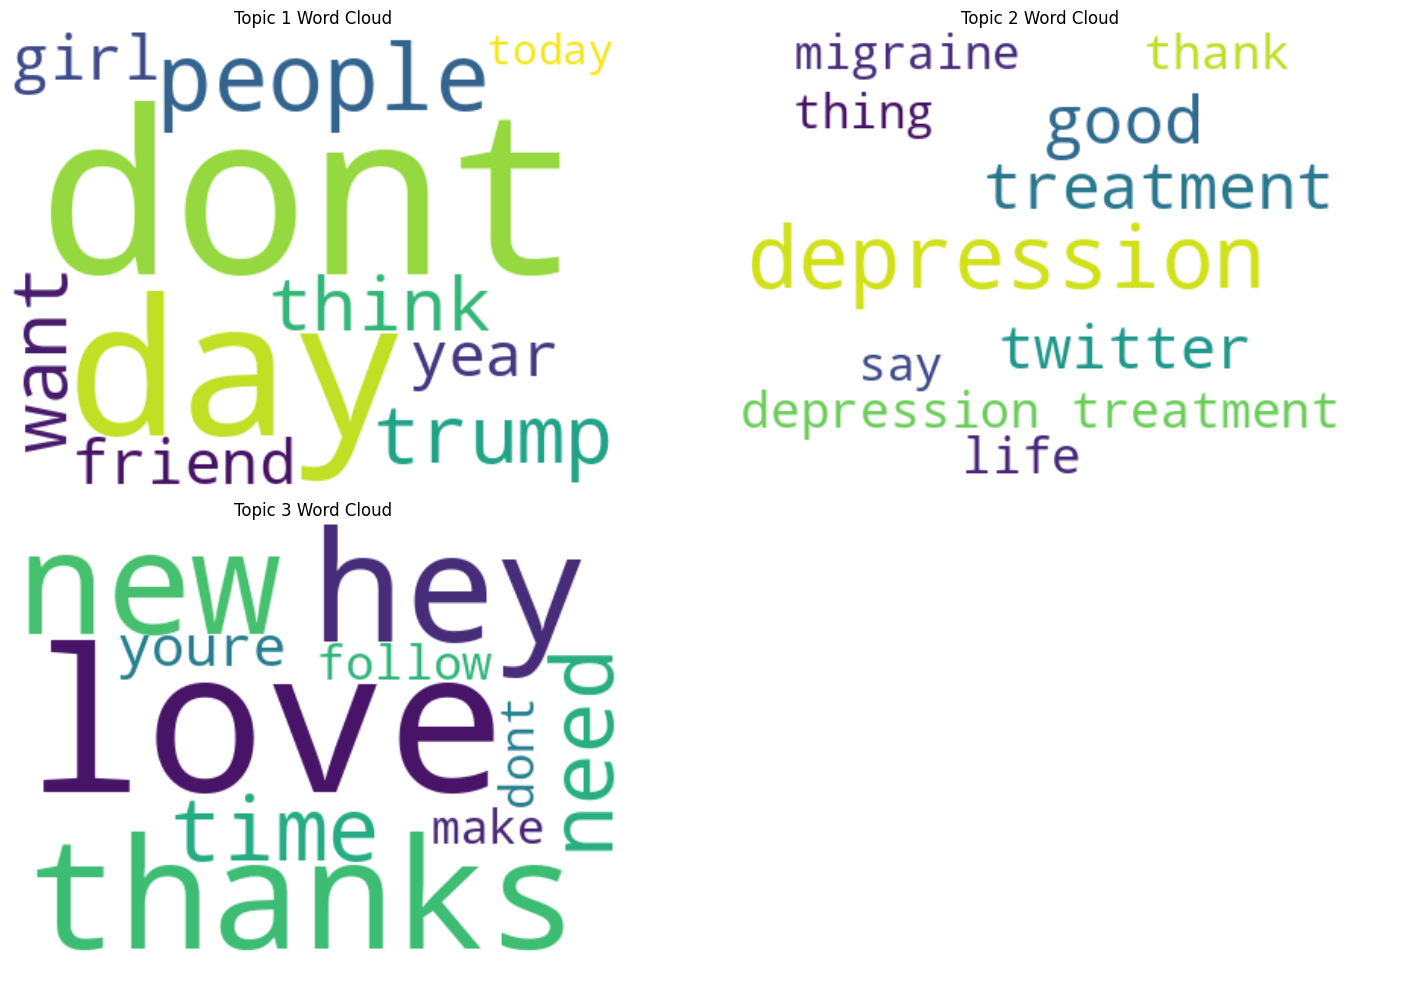

In [26]:
print("\n" + "="*50)
print("WORD CLOUD VISUALIZATION")
print("="*50)

# Create word clouds for each topic
n_cols = 2
n_rows = (optimal_topics + 1) // 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

for topic_idx in range(optimal_topics):
    # Get top words for this topic
    topic_words = topics_info[topic_idx][0][:20]  # Top 20 words
    topic_scores = topics_info[topic_idx][1][:20]

    # Create word frequency dictionary
    word_freq = dict(zip(topic_words, topic_scores))

    # Generate word cloud
    wordcloud_obj = WordCloud(width=400, height=300,
                             background_color='white',
                             colormap='viridis').generate_from_frequencies(word_freq)

    # Plot word cloud
    axes[topic_idx].imshow(wordcloud_obj, interpolation='bilinear')
    axes[topic_idx].set_title(f'Topic {topic_idx + 1} Word Cloud')
    axes[topic_idx].axis('off')

# Hide any unused subplots
for idx in range(optimal_topics, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## 11. Model Evaluation and Topic Coherence
We evaluate the coherence of LDA topics, compare them to K-Means clusters, and analyze their relationship to mental health labels.


In [27]:
print("\n" + "="*50)
print("MODEL EVALUATION AND COMPARISON")
print("="*50)

# Compare LDA and K-Means clustering results
comparison_df = pd.crosstab(df_sample['dominant_topic'], df_sample['kmeans_cluster'])
print("LDA Topics vs K-Means Clusters Cross-tabulation:")
print(comparison_df)

# Topic coherence analysis
def analyze_topic_coherence(df, topic_col, text_col):
    """Analyze coherence within topics"""
    coherence_scores = []

    for topic in df[topic_col].unique():
        topic_texts = df[df[topic_col] == topic][text_col].tolist()
        combined_text = ' '.join(topic_texts)

        # Calculate basic coherence metrics
        words = combined_text.split()
        unique_words = len(set(words))
        total_words = len(words)
        diversity = unique_words / total_words if total_words > 0 else 0

        coherence_scores.append({
            'topic': topic,
            'documents': len(topic_texts),
            'total_words': total_words,
            'unique_words': unique_words,
            'diversity': diversity
        })

    return pd.DataFrame(coherence_scores)

# Analyze LDA topic coherence
lda_coherence = analyze_topic_coherence(df_sample, 'dominant_topic', 'processed_text')
print("\nLDA Topic Coherence Analysis:")
print(lda_coherence)

# Analyze relationship between topics and mental health status
print("\nTopic-Status Relationship Analysis:")
for topic in range(optimal_topics):
    topic_data = df_sample[df_sample['dominant_topic'] == topic]
    status_dist = topic_data['status'].value_counts(normalize=True)
    print(f"\nTopic {topic + 1} status distribution:")
    print(status_dist)


MODEL EVALUATION AND COMPARISON
LDA Topics vs K-Means Clusters Cross-tabulation:
kmeans_cluster   0   1   2    3     4   5   6    7    8
dominant_topic                                         
0               27  69  26    5  1760   0  52   63  135
1               62  62  10  151   927  57  21   33   25
2               26  78  94    6  1122   0  38  107   44

LDA Topic Coherence Analysis:
   topic  documents  total_words  unique_words  diversity
0      2       1515         9316          3499   0.375590
1      1       1348         8577          3265   0.380669
2      0       2137        11122          4495   0.404154

Topic-Status Relationship Analysis:

Topic 1 status distribution:
status
0    0.547496
1    0.452504
Name: proportion, dtype: float64

Topic 2 status distribution:
status
1    0.594955
0    0.405045
Name: proportion, dtype: float64

Topic 3 status distribution:
status
0    0.50297
1    0.49703
Name: proportion, dtype: float64


## 12. Summary and Key Insights
We summarize key takeaways from the analysis, including optimal model parameters, discovered topics, and their relevance to mental health.


In [28]:
print("\n" + "="*60)
print("ANALYSIS SUMMARY AND KEY INSIGHTS")
print("="*60)

print(f"Dataset Overview:")
print(f"- Total documents analyzed: {len(df_sample)}")
print(f"- Mental health status distribution: {dict(status_counts)}")
print(f"- Average text length: {df_sample['text_length'].mean():.1f} characters")
print(f"- Average word count: {df_sample['word_count'].mean():.1f} words")

print(f"\nTopic Modeling Results:")
print(f"- Optimal number of topics (LDA): {optimal_topics}")
print(f"- Optimal number of clusters (K-Means): {optimal_k}")
print(f"- Best silhouette score: {max(sil_scores):.3f}")

print(f"\nKey Topics Identified:")
for i, (words, scores) in enumerate(topics_info):
    print(f"Topic {i+1}: {', '.join(words[:5])}")

print(f"\nModel Performance:")
print(f"- LDA perplexity: {min(perplexities):.2f}")
print(f"- Average topic probability: {df_sample['topic_probability'].mean():.3f}")

# Save results for further analysis
results_summary = {
    'dataset_size': len(df_sample),
    'optimal_topics': optimal_topics,
    'optimal_clusters': optimal_k,
    'best_silhouette': max(sil_scores),
    'topics': [words[:10] for words, scores in topics_info],
    'topic_distribution': dict(topic_distribution),
    'status_distribution': dict(status_counts)
}

print(f"\nAnalysis completed successfully!")
print(f"All visualizations and results have been generated.")
print(f"The topic modeling analysis reveals distinct patterns in mental health discussions on social media.")

# Save the processed dataset with topic assignments to Google Drive
df_sample.to_csv('/content/drive/MyDrive/final_topic_results.csv', index=False)
print(f"\nProcessed dataset with topic assignments saved to Google Drive: 'final_topic_results.csv'")

print(f"\nAnalysis completed successfully!")
print(f"All visualizations and results have been generated.")
print(f"The topic modeling analysis reveals distinct patterns in mental health discussions on social media.")


ANALYSIS SUMMARY AND KEY INSIGHTS
Dataset Overview:
- Total documents analyzed: 5000
- Mental health status distribution: {1: np.int64(2522), 0: np.int64(2478)}
- Average text length: 38.1 characters
- Average word count: 5.8 words

Topic Modeling Results:
- Optimal number of topics (LDA): 3
- Optimal number of clusters (K-Means): 9
- Best silhouette score: 0.053

Key Topics Identified:
Topic 1: dont, day, people, trump, want
Topic 2: depression, good, treatment, twitter, depression treatment
Topic 3: love, thanks, hey, new, time

Model Performance:
- LDA perplexity: 1383.38
- Average topic probability: 0.780

Analysis completed successfully!
All visualizations and results have been generated.
The topic modeling analysis reveals distinct patterns in mental health discussions on social media.

Processed dataset with topic assignments saved to Google Drive: 'final_topic_results.csv'

Analysis completed successfully!
All visualizations and results have been generated.
The topic modeling 